# 5. Изображения, цвет и маски

Фотография, массив чисел, обработка по пикселям

Данные: папка data или [lab5_data.zip](lab5_data.zip). В Colab архив загружается через Files рядом с ноутбуком

In [1]:
from pathlib import Path
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12, 'axes.unicode_minus': False, 'figure.figsize': (10, 4)})

def asset(name, unchanged=False):
    flag = cv2.IMREAD_UNCHANGED if unchanged else cv2.IMREAD_COLOR
    for folder in [Path('data'), Path('.')]:
        path = folder / name
        if path.is_file():
            result = cv2.imread(str(path), flag)
            break
    else:
        archive = Path('lab5_data.zip')
        if not archive.is_file():
            raise FileNotFoundError('Нужны папка data или архив lab5_data.zip рядом с ноутбуком')
        with zipfile.ZipFile(archive) as z:
            result = cv2.imdecode(np.frombuffer(z.read('data/' + name), np.uint8), flag)
    if result is None:
        raise ValueError('Не удалось прочитать ' + name)
    return result

def show(ax, image, title):
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.set_axis_off()

## 5.1 Изображение начинается с чисел

Строка, столбец, яркость

In [2]:
small = np.array([[0, 64, 128, 255], [255, 128, 64, 0]], dtype=np.uint8)
print(small)
print('Форма:', small.shape, 'Элемент [0, 2]:', small[0, 2])

[[  0  64 128 255]
 [255 128  64   0]]
Форма: (2, 4) Элемент [0, 2]: 128


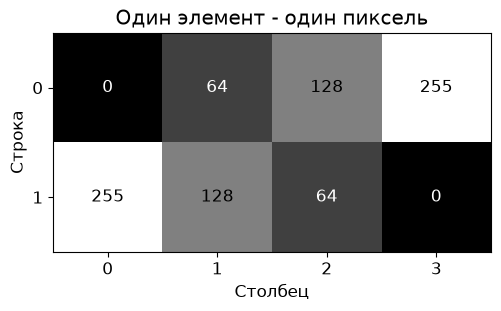

In [3]:
fig, ax = plt.subplots(figsize=(9, 3), layout='constrained')
ax.imshow(small, cmap='gray', vmin=0, vmax=255)
for row, col in np.ndindex(small.shape):
    ax.text(col, row, str(small[row, col]), ha='center', va='center',
            color='white' if small[row, col] < 128 else 'black')
ax.set(xticks=range(4), yticks=range(2), xlabel='Столбец', ylabel='Строка', title='Один элемент - один пиксель')
plt.show()

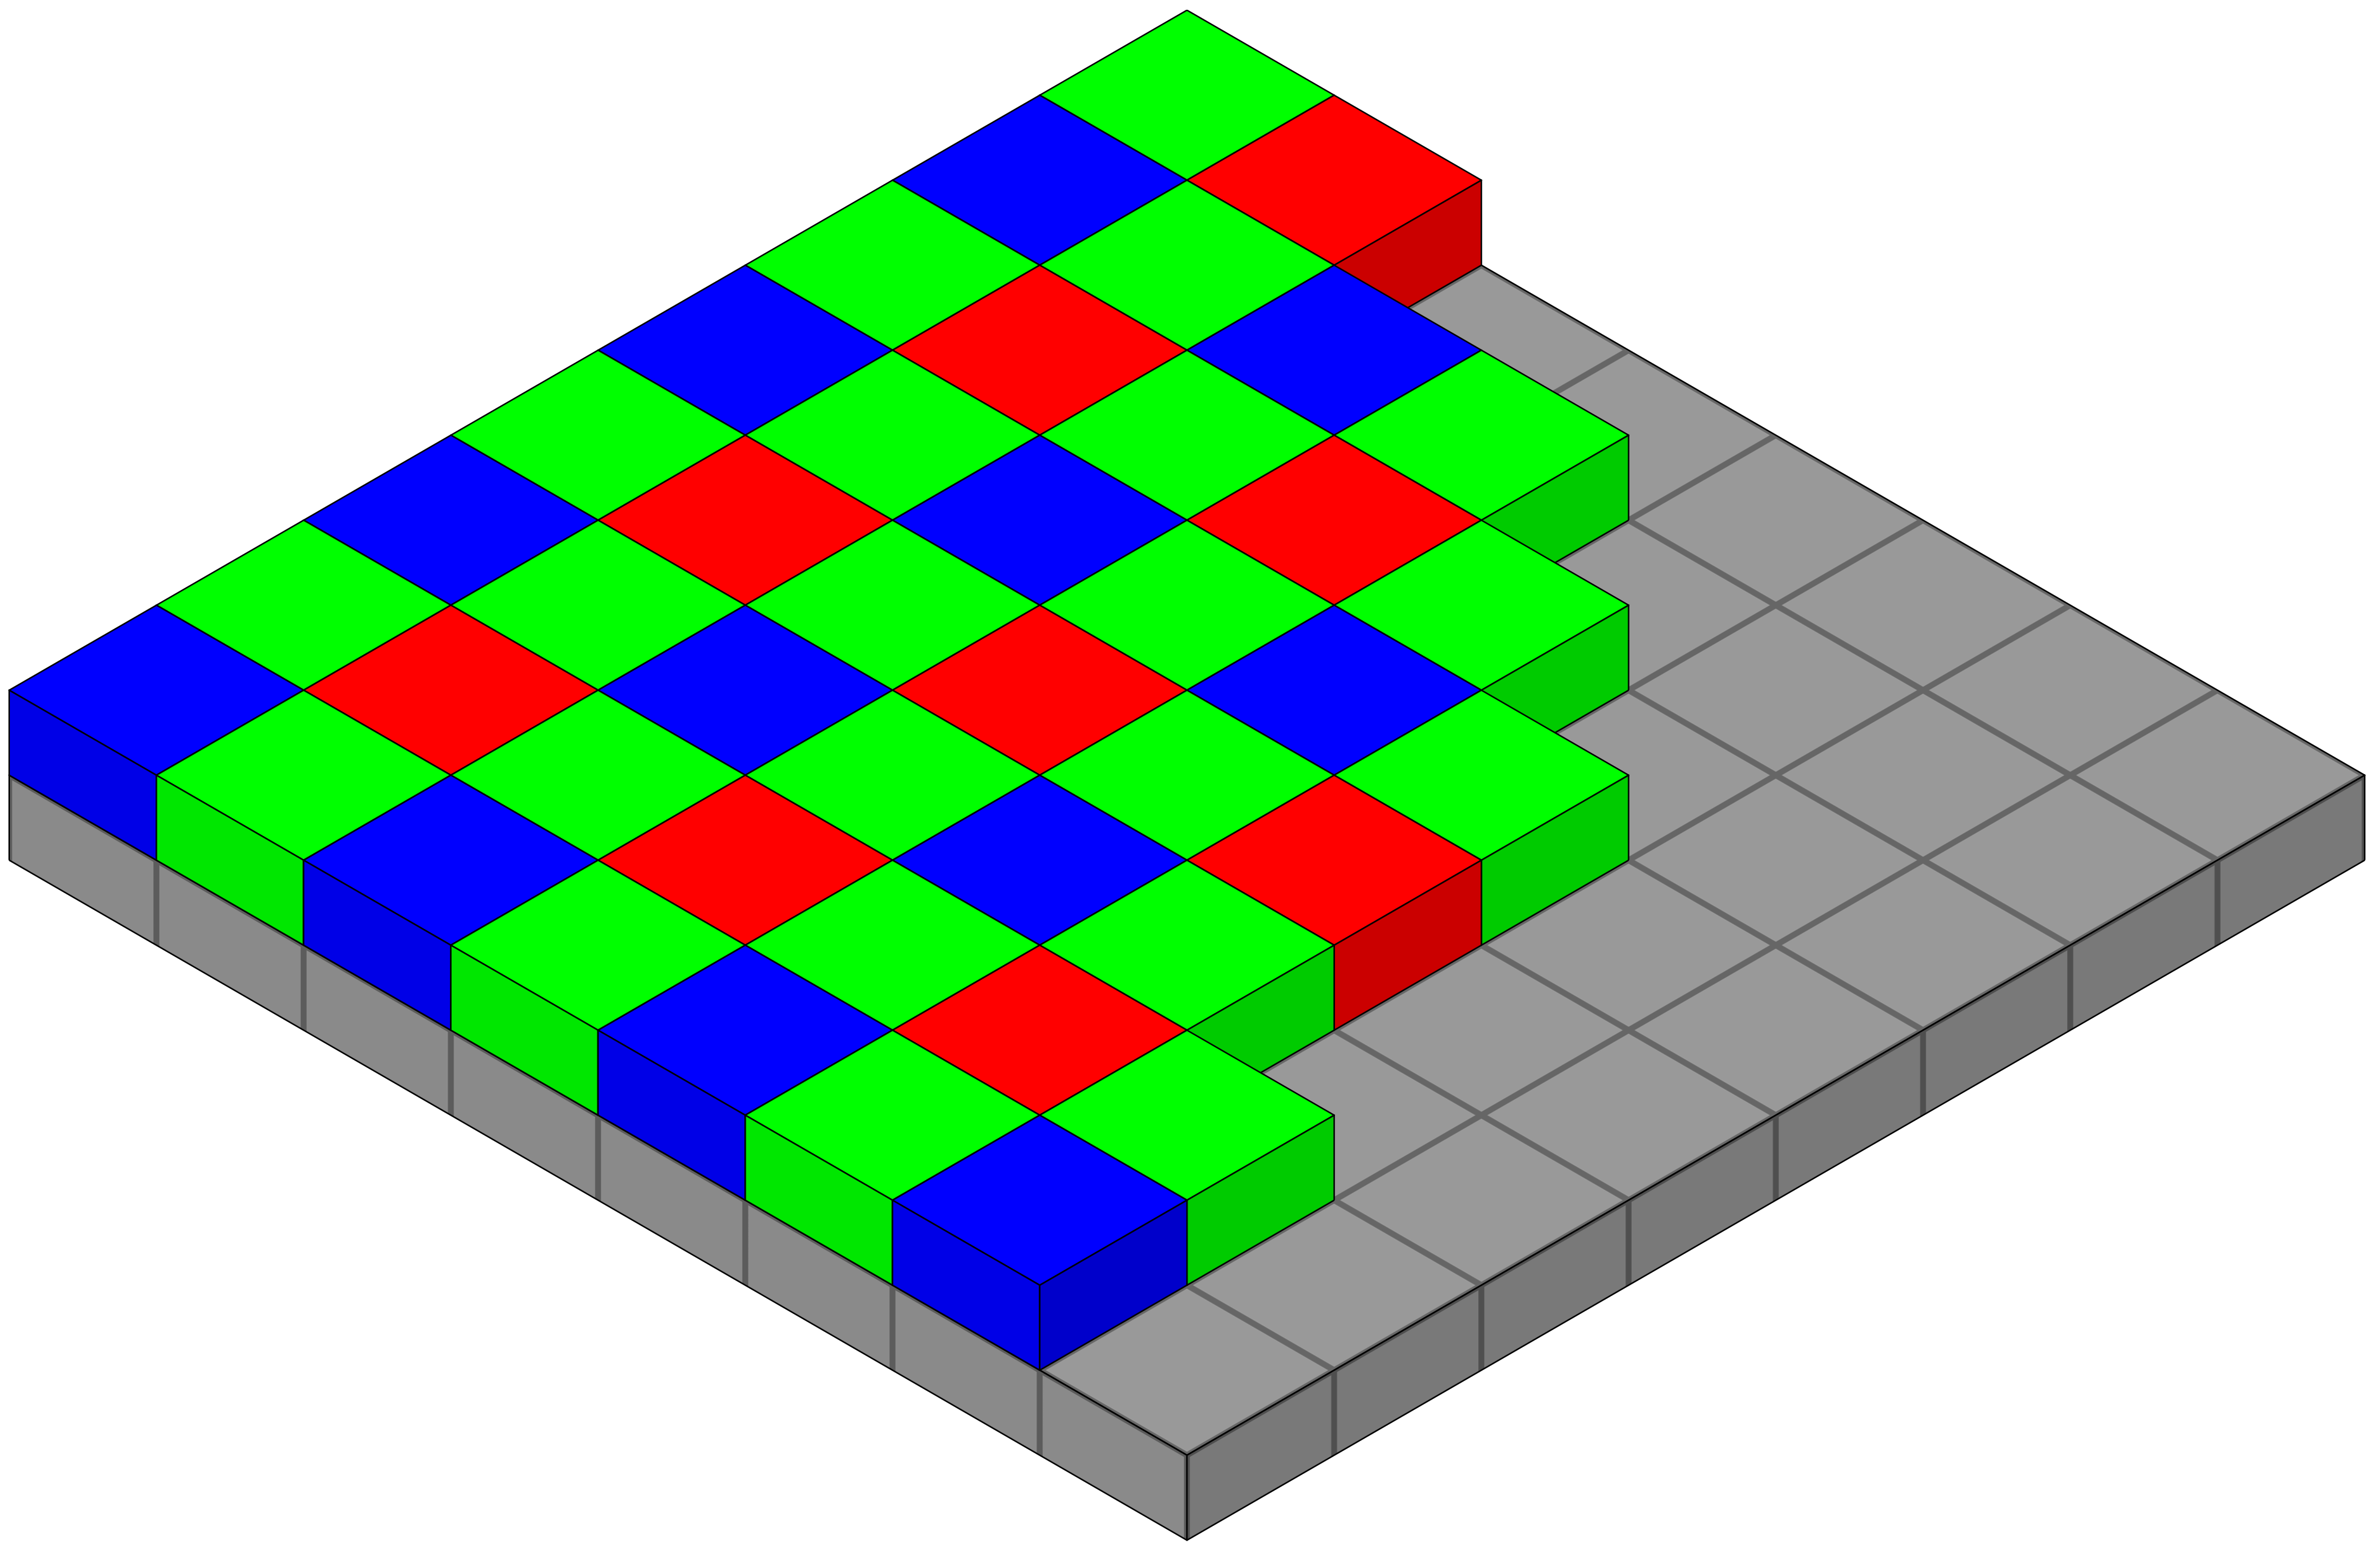

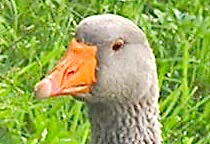

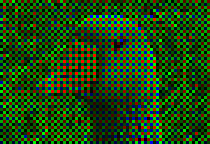

https://ru.wikipedia.org/wiki/Фильтр_Байера

## 5.2 Три числа на цветной пиксель

RGB и BGR отличаются порядком каналов

RGB: [[[255, 0, 0], [0, 255, 0], [0, 0, 255], [120, 120, 120]]]
Фотография HWC: (1024, 768, 3) тип: uint8
Пикселей: 786432 чисел: 2359296


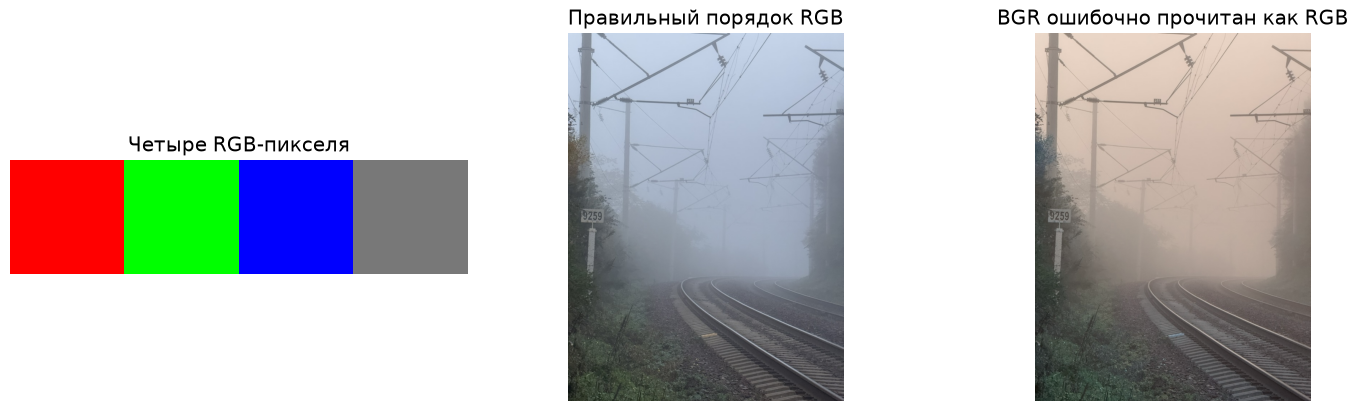

In [4]:
colors = np.array([[[255, 0, 0], [0, 255, 0], [0, 0, 255], [120, 120, 120]]], dtype=np.uint8)
print('RGB:', colors.tolist())
photo = asset('photo.jpeg')
print('Фотография HWC:', photo.shape, 'тип:', photo.dtype)
print('Пикселей:', np.prod(photo.shape[:2]), 'чисел:', photo.size)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
axes[0].imshow(colors)
axes[0].set_title('Четыре RGB-пикселя')
axes[0].set_axis_off()
show(axes[1], photo, 'Правильный порядок RGB')
axes[2].imshow(photo)
axes[2].set_title('BGR ошибочно прочитан как RGB')
axes[2].set_axis_off()
plt.show()

## 5.3 Канал и серое изображение

Светлый пиксель канала означает большое значение компонента

Серый пиксель примерно равен 0.299*R + 0.587*G + 0.114*B


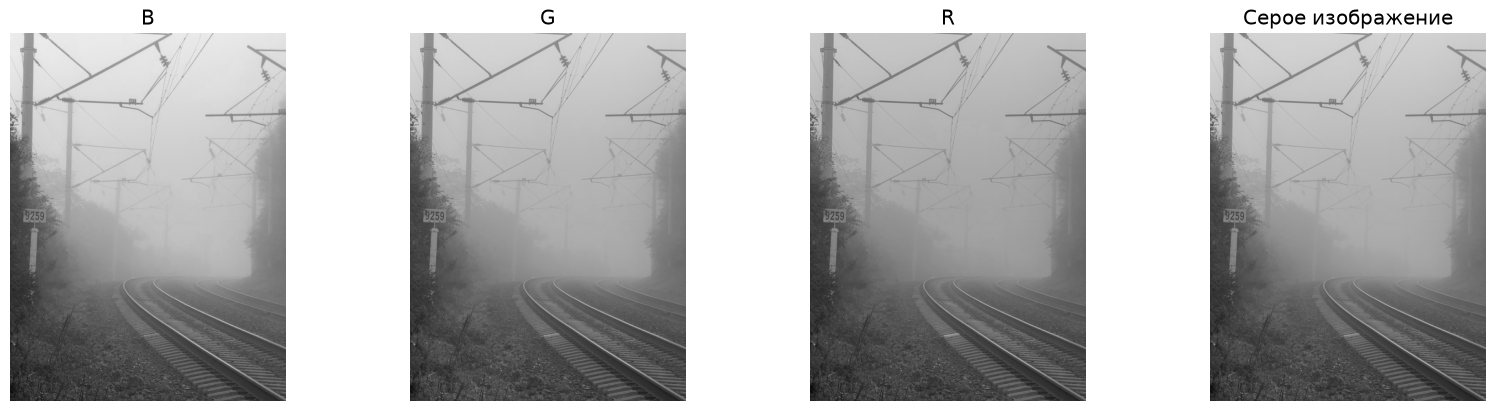

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout='constrained')
channels = list(cv2.split(photo)) + [cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)]
for ax, values, title in zip(axes, channels, ['B', 'G', 'R', 'Серое изображение']):
    ax.imshow(values, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.set_axis_off()
print('Серый пиксель примерно равен 0.299*R + 0.587*G + 0.114*B')
plt.show()

## 5.4 Арифметика яркостей

uint8 хранит только целые числа от 0 до 255

In [6]:
a = np.array([240], dtype=np.uint8)
b = np.array([30], dtype=np.uint8)
print('Сложение uint8:', a + b)
print('После перевода в float32:', a.astype(np.float32) + b)
print('После ограничения:', np.clip(a.astype(np.float32) + b, 0, 255).astype(np.uint8))

Сложение uint8: [14]
После перевода в float32: [270.]
После ограничения: [255]


## 5.5 Поиск лица

Детекция находит рамку, но не определяет личность

Видимых лиц на исходной фотографии: 14


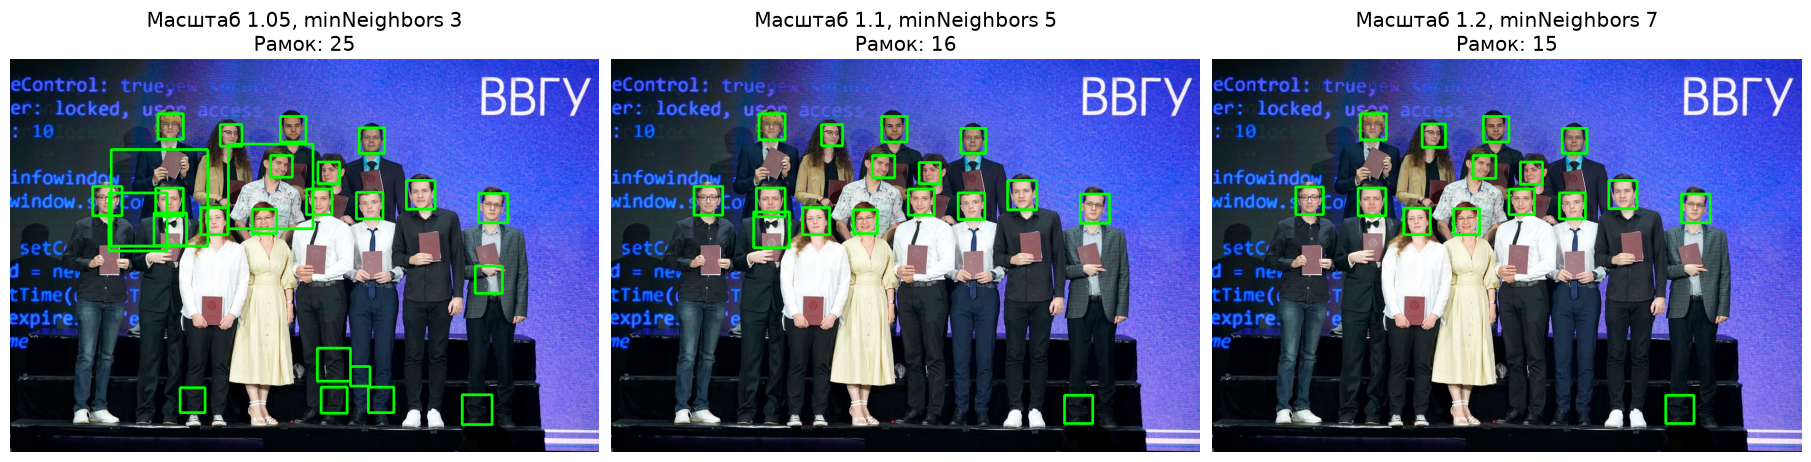

In [7]:
detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
assert not detector.empty()
group_photo = asset('group_photo.jpeg')
gray_photo = cv2.cvtColor(group_photo, cv2.COLOR_BGR2GRAY)
print('Видимых лиц на исходной фотографии: 14')
fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout='constrained')
for ax, scale, neighbors in zip(axes, [1.05, 1.1, 1.2], [3, 5, 7]):
    faces = detector.detectMultiScale(gray_photo, scaleFactor=scale, minNeighbors=neighbors, minSize=(30, 30))
    marked = group_photo.copy()
    for x, y, w, h in faces:
        cv2.rectangle(marked, (x, y), (x + w, y + h), (0, 255, 0), 3)
    show(ax, marked, f'Масштаб {scale}, minNeighbors {neighbors}\nРамок: {len(faces)}')
plt.show()

## 5.6 Прозрачность - взвешенная сумма

Результат = alpha * передний план + (1 - alpha) * фон

Результат: 125.0


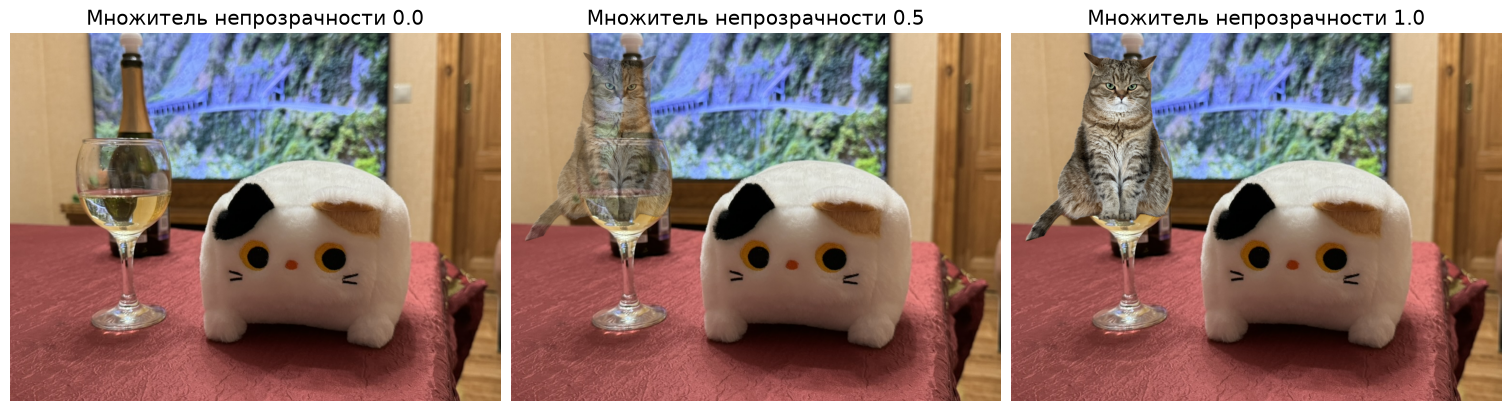

In [8]:
background_value, foreground_value, alpha = 100, 200, 0.25
print('Результат:', alpha * foreground_value + (1 - alpha) * background_value)
base = asset('base_photo.jpeg')
layer = asset('cat_sticker.png', unchanged=True)
w = round(base.shape[1] * 0.3)
h = round(layer.shape[0] * w / layer.shape[1])
layer = cv2.resize(layer, (w, h), interpolation=cv2.INTER_AREA)
x0, y0 = 30, 40
opacity = layer[:, :, 3:4].astype(np.float32) / 255
region = base[y0:y0+h, x0:x0+w].astype(np.float32)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), layout='constrained')
for ax, strength in zip(axes, [0.0, 0.5, 1.0]):
    out = base.copy()
    a = strength * opacity
    out[y0:y0+h, x0:x0+w] = np.clip(a * layer[:, :, :3] + (1 - a) * region, 0, 255).astype(np.uint8)
    show(ax, out, f'Множитель непрозрачности {strength}')
plt.show()

## 5.7 HSV: тон, насыщенность, яркость

H: 0-179, S и V: 0-255 в 8-битном OpenCV

![rgb vs hsv](rgb-vs-hsv.jpg)

RGB: [[0, 255, 0], [0, 90, 0], [120, 140, 120], [200, 200, 200]]
HSV: [[60, 255, 255], [60, 255, 90], [60, 36, 140], [0, 0, 200]]


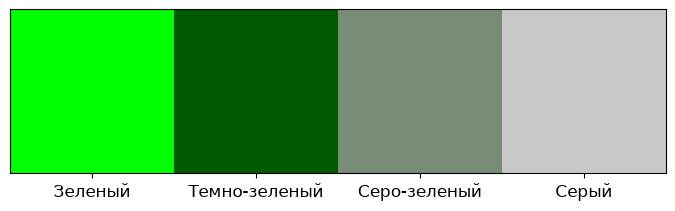

In [9]:
rgb_examples = np.array([[[0, 255, 0], [0, 90, 0], [120, 140, 120], [200, 200, 200]]], dtype=np.uint8)
hsv_examples = cv2.cvtColor(rgb_examples, cv2.COLOR_RGB2HSV)
print('RGB:', rgb_examples[0].tolist())
print('HSV:', hsv_examples[0].tolist())
fig, ax = plt.subplots(figsize=(10, 2), layout='constrained')
ax.imshow(rgb_examples)
ax.set(xticks=range(4), xticklabels=['Зеленый', 'Темно-зеленый', 'Серо-зеленый', 'Серый'], yticks=[])
plt.show()

## 5.8 Маска выбирает пиксели

Белое - заменить фон, черное - оставить исходный кадр

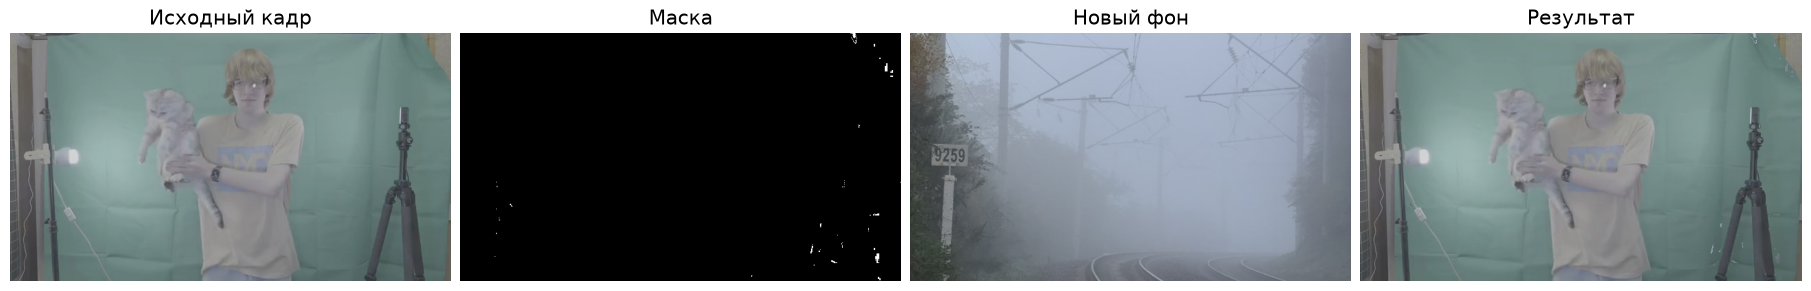

Доля замененных пикселей: 0.001


In [10]:
# Для видео из архива извлекается только указанный файл
video_path = Path('data/demo_video.mp4')
if not video_path.exists():
    video_path = Path('demo_video.mp4')
if not video_path.exists():
    with zipfile.ZipFile('lab5_data.zip') as z:
        video_path.write_bytes(z.read('data/demo_video.mp4'))
cap = cv2.VideoCapture(str(video_path))
try:
    if not cap.isOpened():
        raise ValueError('Не удалось открыть видео')
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, 30)
    ok, frame = cap.read()
    if not ok:
        raise ValueError('Не удалось прочитать кадр 30')
finally:
    cap.release()
# Сохраняем пропорции фона, обрезая края
background = asset('photo.jpeg')
h, w = frame.shape[:2]
scale = max(w / background.shape[1], h / background.shape[0])
resized = cv2.resize(background, (int(np.ceil(background.shape[1]*scale)), int(np.ceil(background.shape[0]*scale))))
x0, y0 = (resized.shape[1]-w)//2, (resized.shape[0]-h)//2
bg = resized[y0:y0+h, x0:x0+w]

def chroma_demo(lower=(45, 15, 20), upper=(95, 255, 255)):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array(lower, np.uint8), np.array(upper, np.uint8))
    result = np.where(mask[:, :, None] == 255, bg, frame)
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), layout='constrained')
    show(axes[0], frame, 'Исходный кадр')
    axes[1].imshow(mask, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title('Маска')
    axes[1].set_axis_off()
    show(axes[2], bg, 'Новый фон')
    show(axes[3], result, 'Результат')
    plt.show()
    print('Доля замененных пикселей:', round(float(np.mean(mask == 255)), 3))

# Более строгая граница по насыщенности оставляет часть бледного фона
chroma_demo((35, 60, 50), (85, 255, 255))

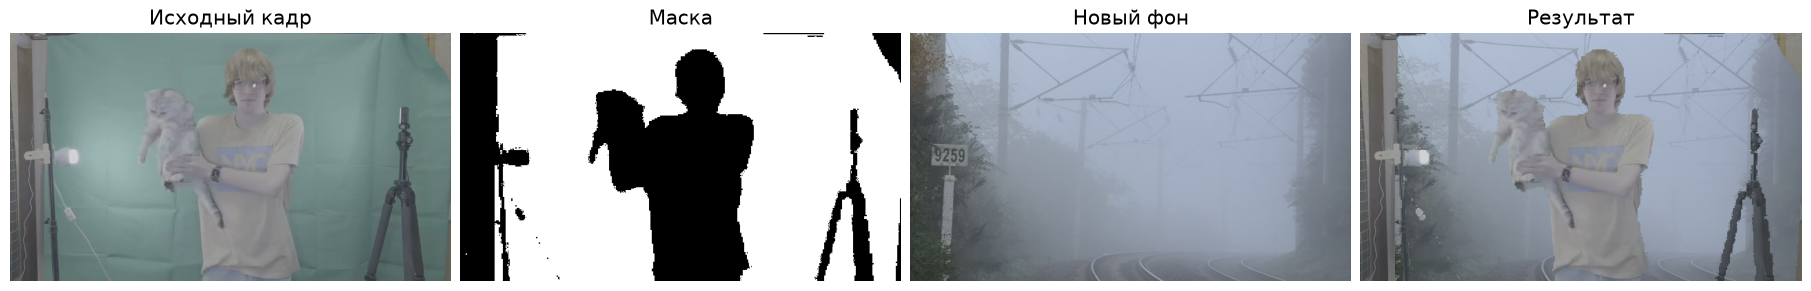

Доля замененных пикселей: 0.663


In [ ]:
chroma_demo((45, 15, 20), (95, 255, 255))

## 5.9 Кадры и время

Время кадра = номер / FPS

FPS: 30.0 Число кадров: 520
Кадры: [  0  30 260 519]
Время, с: [ 0.          1.          8.66666667 17.3       ]
Длительность: 17.333333333333332 с


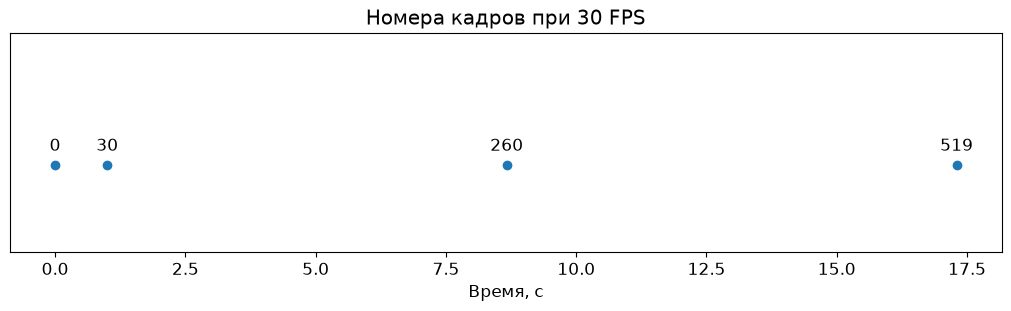

In [12]:
indices = np.array([0, 30, 260, frame_count - 1])
print('FPS:', fps, 'Число кадров:', frame_count)
print('Кадры:', indices)
print('Время, с:', indices / fps)
print('Длительность:', frame_count / fps, 'с')
fig, ax = plt.subplots(figsize=(10, 3), layout='constrained')
ax.scatter(indices / fps, np.ones(len(indices)))
for i, t in zip(indices, indices / fps):
    ax.annotate(str(i), (t, 1), xytext=(0, 10), textcoords='offset points', ha='center')
ax.set(xlabel='Время, с', yticks=[], ylim=(0.8, 1.3), title=f'Номера кадров при {fps:g} FPS')
plt.show()